# DATA 612 — Project 2: Content-Based and Collaborative Filtering

**Name:** Noah Collin  **Course:** DATA 612

## The problem I'm solving

Basically I'm building something that **recommends movies to people**. Everyone has rated some
movies from 0.5 to 5 stars, but nobody has watched more than a tiny slice of the whole catalog, so
the big ratings table is mostly holes. The whole game here is to *guess what rating a viewer would
give a movie they haven't seen yet*, and then hand them the movies with the highest guesses.

## What I actually do here

The assignment only asks for **two** algorithms, but honestly once I had the machinery set up it
wasn't much extra work to do all three of the classic approaches and put them head to head:

| Approach | The one-line version |
|---|---|
| **Content-Based Filtering** | Recommend movies whose *content* (genre, tags, plot summary) looks like stuff you already liked. |
| **User-User Collaborative Filtering** | Recommend what *people who are similar to you* liked. |
| **Item-Item Collaborative Filtering** | Recommend movies that get *rated similarly* to ones you liked. |

After that I fiddle with the knobs the assignment calls out — **neighborhood size**, **similarity
metric**, and **normalization** — and then compare everything with **RMSE** plus a **Precision@K /
Recall@K** ranking check. There's charts and a written wrap-up at the end.

## The data

I'm using the **MovieLens `ml-latest-small`** dataset (about 100K ratings, 610 users, 9,724 movies)
and bolting on **plot summaries from TMDb** (the "The Movies Dataset" Kaggle dump), joined through
MovieLens's `links.csv`. MovieLens hands me the ratings, genres and user tags; TMDb gives me the
actual text I need to make content-based filtering do anything interesting.

## Setup

Just imports, file paths, and a little helper that downloads MovieLens for me if it's not already
sitting on disk (so this runs from a fresh clone without me having to remember to grab the data).
Everything runs in the `data612` virtual-environment kernel — see the repo README.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import urllib.request, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
sns.set_theme(style="whitegrid")
RNG = np.random.RandomState(42)   # fixed seed so the train/test split is the same every run

# --- find the shared data folder (it sits one level up from this project folder) ---
DATA = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), Path("../data"))
ML = DATA / "movielens" / "ml-latest-small"

# grab MovieLens if I don't already have it, so this works from a fresh clone
if not (ML / "ratings.csv").exists():
    print("Downloading MovieLens ml-latest-small ...")
    ML.parent.mkdir(parents=True, exist_ok=True)
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    with urllib.request.urlopen(url) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(ML.parent)
print("MovieLens folder:", ML.resolve())

MovieLens folder: C:\Users\noahc\Dropbox\NotWork\CUNYSPS\2026\Summer 2026\data\movielens\ml-latest-small


## Load the data and have a look

I'm pulling in four MovieLens files plus the TMDb metadata:

- `ratings.csv` — the (userId, movieId, rating) triples that everything is built on.
- `movies.csv` — movie titles and pipe-separated **genres**.
- `tags.csv` — free-text **tags** people stuck on movies.
- `links.csv` — the bridge from MovieLens `movieId` over to **`tmdbId`** (and IMDb).
- TMDb `movies_metadata.csv` — the **plot `overview`** text, which is what makes content-based filtering possible.

In [2]:
ratings = pd.read_csv(ML / "ratings.csv")
movies  = pd.read_csv(ML / "movies.csv")
tags    = pd.read_csv(ML / "tags.csv")
links   = pd.read_csv(ML / "links.csv")

print(f"ratings : {ratings.shape[0]:,} rows | {ratings.userId.nunique()} users | {ratings.movieId.nunique()} movies")
print(f"movies  : {movies.shape[0]:,} | tags: {tags.shape[0]:,} | links: {links.shape[0]:,}")
density = ratings.shape[0] / (ratings.userId.nunique() * ratings.movieId.nunique())
print(f"matrix density: {density:.2%}  (so {1-density:.2%} of the user-item matrix is just empty)")
ratings.head()

ratings : 100,836 rows | 610 users | 9724 movies
movies  : 9,742 | tags: 3,683 | links: 9,742
matrix density: 1.70%  (so 98.30% of the user-item matrix is just empty)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### A quick look around

Two things I really want to know before building anything: **how the ratings are spread out** (are
people generous, or harsh?) and **how sparse this thing is** (how many ratings does each user and
each movie actually have?).

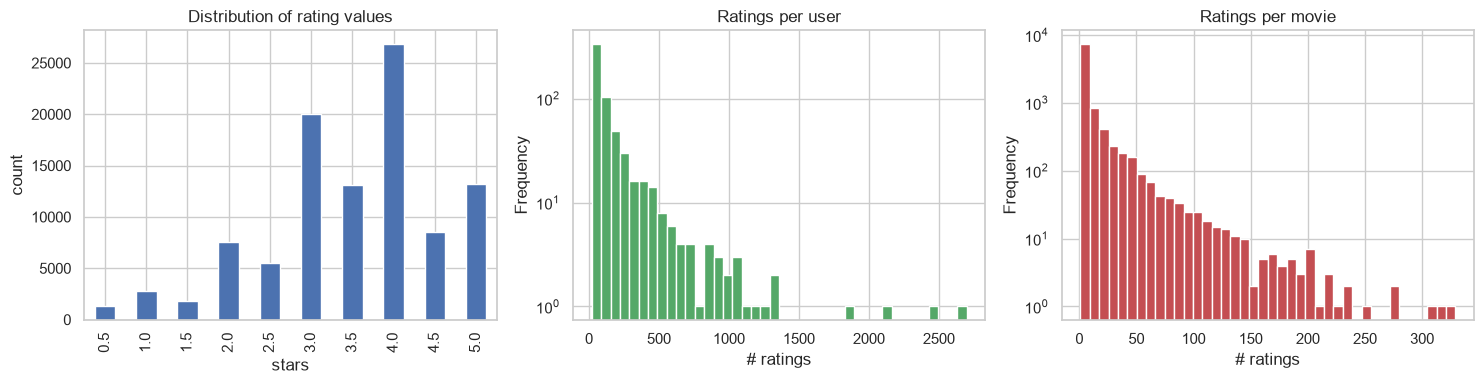

Most users rate few movies and most movies get few ratings — the classic long tail.


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) how the actual star values break down
ratings.rating.value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribution of rating values"); ax[0].set_xlabel("stars"); ax[0].set_ylabel("count")

# (b) ratings per user (log scale because the tail is heavy)
ratings.groupby("userId").size().plot(kind="hist", bins=40, ax=ax[1], color="#55A868")
ax[1].set_title("Ratings per user"); ax[1].set_xlabel("# ratings"); ax[1].set_yscale("log")

# (c) ratings per movie (log scale — most movies barely get rated)
ratings.groupby("movieId").size().plot(kind="hist", bins=40, ax=ax[2], color="#C44E52")
ax[2].set_title("Ratings per movie"); ax[2].set_xlabel("# ratings"); ax[2].set_yscale("log")
plt.tight_layout(); plt.show()
print("Most users rate few movies and most movies get few ratings — the classic long tail.")

## Trim down to a denser core

A movie with only one or two ratings gives you **garbage similarities** — there's just not enough
to compare against — and it also bloats the item-item similarity matrix. So the standard move is to
toss the movies almost nobody rated. I keep movies with **≥ 10 ratings**. The users in
`ml-latest-small` already have ≥ 20 ratings each, so I leave the users alone.

The payoff is faster math, steadier similarities, and a fairer RMSE comparison. The tradeoff is I
won't be recommending the really obscure stuff — I come back to that limitation at the end.

In [4]:
MIN_RATINGS = 10
counts = ratings.groupby("movieId").size()
keep = counts[counts >= MIN_RATINGS].index
r = ratings[ratings.movieId.isin(keep)].copy()
print(f"Kept movies with >= {MIN_RATINGS} ratings: "
      f"{r.movieId.nunique()} of {ratings.movieId.nunique()} movies, "
      f"{len(r):,} of {len(ratings):,} ratings "
      f"({r.movieId.nunique()/ratings.movieId.nunique():.0%} of movies, {len(r)/len(ratings):.0%} of ratings).")

Kept movies with >= 10 ratings: 2269 of 9724 movies, 81,116 of 100,836 ratings (23% of movies, 80% of ratings).


## Train / test split and the user-item matrix

I set aside a random **20%** of the ratings as a test set and build everything — the means, the
similarities, all of it — **only from the other 80%**. Then I can fairly check how well each model
predicts the ratings it never got to see.

While I'm here I set up the pieces every method ends up reusing:

- `R` — the training user×item matrix (`NaN` means not rated).
- `user_mean` — each user's average rating in training.
- `Rc` — the **mean-centered** matrix (each rating minus that user's mean), with 0 in the empty cells.
  Centering cancels out the "some people just rate everything high" effect, so similarity ends up
  comparing *taste* instead of *generosity*. This is the **normalization** knob the assignment wants
  me to play with.

In [5]:
# random 80/20 split on the individual rating events
test_mask = RNG.rand(len(r)) < 0.20
test  = r[test_mask].copy()
train = r[~test_mask].copy()
print(f"train: {len(train):,}   test: {len(test):,}")

# the training user-item matrix
M = train.pivot_table(index="userId", columns="movieId", values="rating")
users = M.index.to_numpy(); items = M.columns.to_numpy()
uidx = {u: i for i, u in enumerate(users)}     # userId  -> row index
iidx = {m: j for j, m in enumerate(items)}     # movieId -> col index

R = M.to_numpy(dtype=float)                     # NaN wherever it wasn't rated
rated = ~np.isnan(R)                            # mask of which cells were actually observed
user_mean = np.nanmean(R, axis=1)               # each user's training mean
Rc = np.where(rated, R - user_mean[:, None], 0.0)  # mean-centered; empty cells become 0
print("user-item matrix:", R.shape, f"({rated.sum():,} observed cells)")

train: 64,963   test: 16,153
user-item matrix: (610, 2269) (64,963 observed cells)


In [6]:
# --- helpers I reuse all over the place -------------------------------------
def rmse_on_test(pred_matrix):
    # take a full (users x items) prediction matrix and score it against the held-out ratings
    te = test[test.userId.isin(uidx) & test.movieId.isin(iidx)]
    ui = te.userId.map(uidx).to_numpy()
    ii = te.movieId.map(iidx).to_numpy()
    pred = pred_matrix[ui, ii]
    return float(np.sqrt(np.mean((pred - te.rating.to_numpy()) ** 2)))

def keep_topk(S, k):
    # for each row, keep only its top-k closest neighbours (by |similarity|) and zero out the rest.
    # also drops the diagonal so nothing is its own neighbour.
    Sk = S.copy()
    np.fill_diagonal(Sk, 0.0)
    if k is not None and k < Sk.shape[1]:
        drop = np.argpartition(-np.abs(Sk), k, axis=1)[:, k:]   # everything past the top-k
        np.put_along_axis(Sk, drop, 0.0, axis=1)
    return Sk

def neighbourhood_predict(sim, axis, k):
    # one prediction routine for both CF flavours, working off the centered matrix.
    # axis='user': sim is users x users.  axis='item': sim is items x items.
    # the prediction is user_mean + (weighted sum of neighbour deviations) / (sum of |weights|).
    Sk = keep_topk(sim, k)
    if axis == "user":
        num = Sk @ Rc                 # (users x users) @ (users x items)
        den = np.abs(Sk) @ rated      # how much neighbour weight actually rated each item
    else:
        num = Rc @ Sk                 # (users x items) @ (items x items)
        den = rated @ np.abs(Sk)
    with np.errstate(invalid="ignore", divide="ignore"):
        pred = user_mean[:, None] + num / den
    pred = np.where(den > 0, pred, user_mean[:, None])   # no neighbours? just fall back to the user's mean
    return np.clip(pred, 0.5, 5.0)

# something to beat: just predict the global training average for every single cell
global_mean = train.rating.mean()
rmse_global = float(np.sqrt(np.mean((global_mean - test.rating.to_numpy()) ** 2)))
print(f"Baseline — predict global mean ({global_mean:.2f}) everywhere: test RMSE = {rmse_global:.4f}")

Baseline — predict global mean (3.57) everywhere: test RMSE = 1.0238


## Method 1 — Content-Based Filtering

**The idea:** describe each movie by its own *content*, then recommend movies whose content looks
like the ones a user already rated highly. The thing is, this never touches anybody else's ratings,
just the movie's own attributes — which means it can happily recommend a brand-new or barely-rated
movie, so there's no "cold-start" headache on the item side.

**Making the item profiles.** For each movie I glue together a little text "profile" out of:

- its **genres** (weighted ×3, since genre is a strong, clean signal),
- its **TMDb plot summary** (`overview`), and
- whatever **user tags** people left (weighted ×2).

Then I turn those profiles into vectors with **TF-IDF** (term frequency × inverse document
frequency), which basically dials down words that show up in almost every movie and dials up the
distinctive ones. The **cosine similarity** between two of those vectors is my content similarity.
From there I predict a rating with the exact same neighbourhood formula as collaborative filtering —
the only swap is I'm feeding it *content* similarity instead of *rating-pattern* similarity.

In [7]:
# --- build a text profile for every movie -----------------------------------
meta_path = DATA / "tmdb" / "movies_metadata.csv"
if meta_path.exists():
    meta = pd.read_csv(meta_path, low_memory=False)
    meta = meta[pd.to_numeric(meta["id"], errors="coerce").notna()]
    meta = meta.assign(tmdbId=meta["id"].astype(float).astype("Int64"))[["tmdbId", "overview"]]
    meta = meta.drop_duplicates(subset="tmdbId")             # the TMDb dump has a handful of duplicate ids
    lk = links.dropna(subset=["tmdbId"]).assign(tmdbId=lambda d: d.tmdbId.astype("Int64"))
    mv = movies.merge(lk[["movieId", "tmdbId"]], on="movieId", how="left") \
               .merge(meta, on="tmdbId", how="left")
    have = mv.loc[mv.movieId.isin(items), "overview"].notna().mean()
    print(f"TMDb plot summaries available for {have:.0%} of the modelled movies.")
else:
    mv = movies.copy(); mv["overview"] = ""
    print("TMDb file not found — content profiles will just use genres + tags.")

# mix in the user tags (one space-joined string per movie)
tag_str = tags.groupby("movieId")["tag"].apply(lambda s: " ".join(map(str, s))).rename("tags")
mv = mv.merge(tag_str, on="movieId", how="left")

mv["genres"]   = mv["genres"].str.replace("|", " ", regex=False).replace("(no genres listed)", "")
mv["overview"] = mv["overview"].fillna("")
mv["tags"]     = mv["tags"].fillna("")
# genres x3, tags x2 just by repeating the text — a cheap way to weight fields in a bag of words
mv["profile"]  = (mv["genres"] + " ") * 3 + mv["overview"] + " " + (mv["tags"] + " ") * 2

profiles = mv.set_index("movieId")["profile"].reindex(items).fillna("")
mv[mv.movieId.isin(items)][["title", "genres"]].head(3)

TMDb plot summaries available for 100% of the modelled movies.


,title,genres
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,Jumanji (1995),Adventure Children Fantasy
2,Grumpier Old Men (1995),Comedy Romance


In [8]:
# --- TF-IDF vectors, then cosine similarity in that content space -----------
tfidf = TfidfVectorizer(stop_words="english", max_features=8000, min_df=2)
X = tfidf.fit_transform(profiles)                 # (movies x vocabulary)
content_sim = cosine_similarity(X)                # (movies x movies)
print("TF-IDF matrix:", X.shape, "| content similarity matrix:", content_sim.shape)

pred_content = neighbourhood_predict(content_sim, axis="item", k=30)
rmse_content = rmse_on_test(pred_content)
print(f"Content-based (k=30) test RMSE = {rmse_content:.4f}")

TF-IDF matrix:

 (2269, 7117) | content similarity matrix: (2269, 2269)
Content-based (k=30) test RMSE = 0.9828


**Quick sanity check — does this similarity actually look right?** If my TF-IDF profiles are any
good, the movies it calls most "content-similar" to a film I know well should pass the gut check.

In [9]:
def most_similar(title_substr, simmat, n=8):
    matches = mv[mv.title.str.contains(title_substr, case=False, na=False) & mv.movieId.isin(items)]
    if matches.empty: return f"no modelled movie matches '{title_substr}'"
    mid = matches.iloc[0].movieId; j = iidx[mid]
    order = np.argsort(-simmat[j])
    out = [(mv.set_index('movieId').loc[items[o], 'title'], round(float(simmat[j, o]), 3))
           for o in order[1:n+1]]
    return pd.DataFrame(out, columns=["most similar movie", "cosine"]).assign(seed=matches.iloc[0].title)

most_similar("Toy Story", content_sim)

,most similar movie,cosine,seed
0,Toy Story 2 (1999),0.578,Toy Story (1995)
1,Toy Story 3 (2010),0.475,Toy Story (1995)
2,"Bug's Life, A (1998)",0.374,Toy Story (1995)
3,Coco (2017),0.284,Toy Story (1995)
4,Man on the Moon (1999),0.256,Toy Story (1995)
5,"Monsters, Inc. (2001)",0.251,Toy Story (1995)
6,Up (2009),0.241,Toy Story (1995)
7,Moana (2016),0.238,Toy Story (1995)


## Method 2 — User-User Collaborative Filtering

**The idea:** to guess how user *u* would rate movie *i*, I go find the users **most like *u*** (based
on how they rated the movies they have in common), and take a similarity-weighted average of *their*
ratings of *i*. The key bit is that "similar" is measured on the **mean-centered** ratings, so two
people count as similar when they *agree about which movies are above or below their own average* —
not just because they both happen to rate everything high.

I use **cosine similarity on the centered matrix**, which (kind of neatly) works out to be exactly
the **Pearson correlation** between users, and then average over each user's **top-k** neighbours.

In [10]:
user_sim = cosine_similarity(Rc)                 # users x users on centered ratings == Pearson
pred_uu = neighbourhood_predict(user_sim, axis="user", k=30)
rmse_uu = rmse_on_test(pred_uu)
print(f"User-User CF (k=30) test RMSE = {rmse_uu:.4f}")

User-User CF (k=30) test RMSE = 0.8894


## Method 3 — Item-Item Collaborative Filtering

**The idea:** flip it around — instead of finding similar *users*, find similar *items*. Two movies
are "similar" if the people who rated both of them tended to rate them the same way (again on the
centered ratings). To guess user *u*'s rating of movie *i*, I take a similarity-weighted average of
*u*'s own ratings on the movies most like *i*. This is famously the thing behind Amazon's "customers
who bought this also bought…", and it's usually steadier than user-user because a movie's rating
pattern drifts a lot slower than a person's taste does.

In [11]:
item_sim = cosine_similarity(Rc.T)              # items x items on centered ratings
pred_ii = neighbourhood_predict(item_sim, axis="item", k=30)
rmse_ii = rmse_on_test(pred_ii)
print(f"Item-Item CF (k=30) test RMSE = {rmse_ii:.4f}")

Item-Item CF (k=30) test RMSE = 0.9200


## Experiment A — neighbourhood size *k*

So how many neighbours should I actually average over? Too few and the predictions get noisy; too
many and I start watering things down with users/items that aren't really that related. The honest
answer is I don't know up front, so I just sweep *k* across a range for both collaborative methods
and plot the test RMSE to see where it lands.

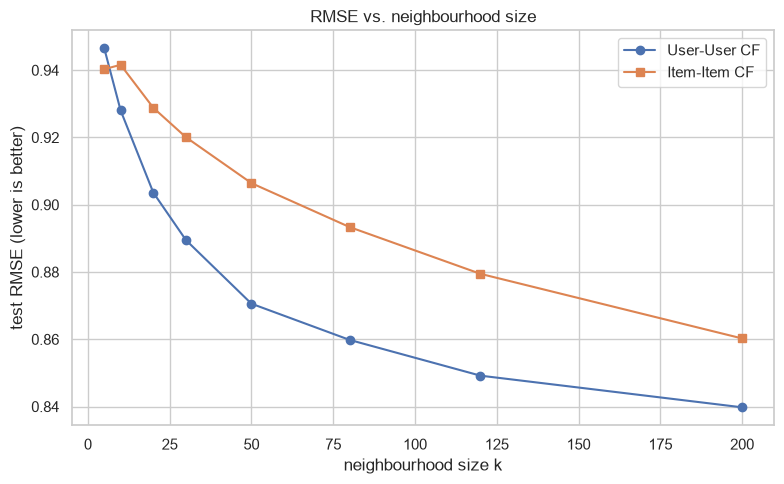

Best k — User-User: 200 (RMSE 0.8398) | Item-Item: 200 (RMSE 0.8602)


In [12]:
ks = [5, 10, 20, 30, 50, 80, 120, 200]
rmse_uu_k = [rmse_on_test(neighbourhood_predict(user_sim, "user", k)) for k in ks]
rmse_ii_k = [rmse_on_test(neighbourhood_predict(item_sim, "item", k)) for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, rmse_uu_k, "o-", label="User-User CF")
plt.plot(ks, rmse_ii_k, "s-", label="Item-Item CF")
plt.xlabel("neighbourhood size k"); plt.ylabel("test RMSE (lower is better)")
plt.title("RMSE vs. neighbourhood size"); plt.legend(); plt.tight_layout(); plt.show()

best_uu_k = ks[int(np.argmin(rmse_uu_k))]; best_ii_k = ks[int(np.argmin(rmse_ii_k))]
print(f"Best k — User-User: {best_uu_k} (RMSE {min(rmse_uu_k):.4f}) | "
      f"Item-Item: {best_ii_k} (RMSE {min(rmse_ii_k):.4f})")

## Experiment B — similarity metric & normalization

The assignment wants me to try different **similarity methods** and **normalization**, so here I put
**raw cosine** similarity (computed on the *uncentered* ratings, with missing cells filled in as 0)
up against the **mean-centered cosine** (= **Pearson**) I've been using. My bet going in is that
centering wins, because it strips out each user's baseline generosity before anything gets compared.

In [13]:
R0 = np.where(rated, R, 0.0)                     # uncentered version, missing cells -> 0

# raw cosine (uncentered) on both axes, run through the SAME neighbourhood machinery.
# with no centering I just predict a weighted average of the actual ratings, so this version
# uses R0/global_mean in place of Rc/user_mean:
def raw_cosine_predict(axis, k):
    sim = cosine_similarity(R0) if axis == "user" else cosine_similarity(R0.T)
    Sk = keep_topk(sim, k)
    if axis == "user":
        num = Sk @ R0; den = np.abs(Sk) @ rated
    else:
        num = R0 @ Sk; den = rated @ np.abs(Sk)
    with np.errstate(invalid="ignore", divide="ignore"):
        pred = num / den
    pred = np.where(den > 0, pred, global_mean)
    return np.clip(pred, 0.5, 5.0)

comp = pd.DataFrame({
    "User-User": [rmse_on_test(raw_cosine_predict("user", 30)), rmse_on_test(neighbourhood_predict(user_sim, "user", 30))],
    "Item-Item": [rmse_on_test(raw_cosine_predict("item", 30)), rmse_on_test(neighbourhood_predict(item_sim, "item", 30))],
}, index=["raw cosine (uncentered)", "mean-centered cosine (Pearson)"])
print(comp.round(4))

                                User-User  Item-Item
raw cosine (uncentered)            0.9620     0.9186
mean-centered cosine (Pearson)     0.8894     0.9200


## Ranking quality — Precision@K and Recall@K

RMSE tells me how close my *predicted numbers* are, but that's not really a recommender's job — its
job is to shove **good movies to the top of a list**. So I also score the *ranking*. For each user I
call their held-out movies rated **≥ 4 stars** the "relevant" ones, have the model recommend its
top-10 movies that user hadn't already rated, and count how many of those land.

- **Precision@10** = out of the 10 I recommended, how many were actually relevant.
- **Recall@10** = out of all the movies the user genuinely liked, how many made it into my top-10.

In [14]:
def precision_recall_at_k(pred_matrix, N=10, thresh=4.0):
    P = pred_matrix.copy()
    P[rated] = -np.inf                                   # don't recommend something they already rated in training
    rel = test[test.rating >= thresh]
    rel_by_user = rel.groupby("userId")["movieId"].apply(set)
    precisions, recalls = [], []
    for u_id, rset in rel_by_user.items():
        if u_id not in uidx: continue
        rset_idx = {iidx[m] for m in rset if m in iidx}
        if not rset_idx: continue
        topN = np.argpartition(-P[uidx[u_id]], N)[:N]
        hits = len(set(topN) & rset_idx)
        precisions.append(hits / N)
        recalls.append(hits / len(rset_idx))
    return float(np.mean(precisions)), float(np.mean(recalls))

rank_rows = {}
for name, P in [("Content-based", pred_content), ("User-User CF", pred_uu), ("Item-Item CF", pred_ii)]:
    p, rc = precision_recall_at_k(P, N=10)
    rank_rows[name] = {"Precision@10": p, "Recall@10": rc}
rank_df = pd.DataFrame(rank_rows).T
print(rank_df.round(4))

               Precision@10  Recall@10
Content-based        0.0112     0.0080
User-User CF         0.0089     0.0057
Item-Item CF         0.0123     0.0060


## Results — pulling it all together

In [15]:
results = pd.DataFrame({
    "Test RMSE":     [rmse_global, rmse_content, rmse_uu, rmse_ii],
    "Precision@10":  [np.nan, rank_df.loc["Content-based","Precision@10"],
                      rank_df.loc["User-User CF","Precision@10"], rank_df.loc["Item-Item CF","Precision@10"]],
    "Recall@10":     [np.nan, rank_df.loc["Content-based","Recall@10"],
                      rank_df.loc["User-User CF","Recall@10"], rank_df.loc["Item-Item CF","Recall@10"]],
}, index=["Global mean (baseline)", "Content-based", "User-User CF", "Item-Item CF"])
results.round(4)

,Test RMSE,Precision@10,Recall@10
Global mean (baseline),1.0238,NaN,NaN
Content-based,0.9828,0.0112,0.0080
User-User CF,0.8894,0.0089,0.0057
Item-Item CF,0.9200,0.0123,0.0060


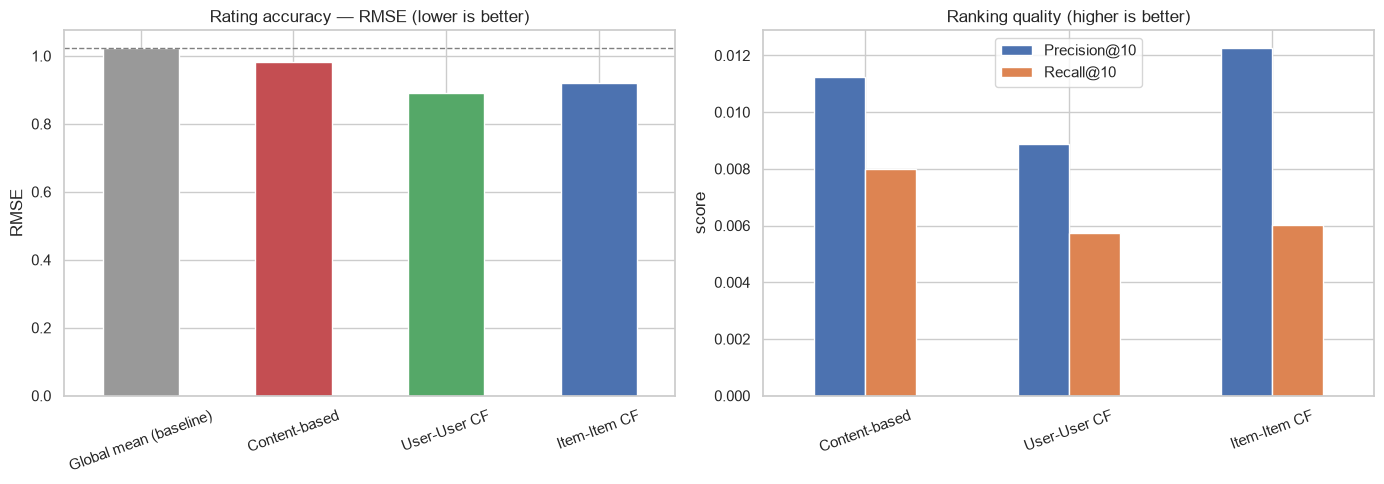

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#999999", "#C44E52", "#55A868", "#4C72B0"]
results["Test RMSE"].plot(kind="bar", ax=ax[0], color=colors)
ax[0].set_title("Rating accuracy — RMSE (lower is better)"); ax[0].set_ylabel("RMSE")
ax[0].axhline(rmse_global, ls="--", c="grey", lw=1); ax[0].tick_params(axis="x", rotation=20)

results.loc[["Content-based","User-User CF","Item-Item CF"], ["Precision@10","Recall@10"]].plot(
    kind="bar", ax=ax[1])
ax[1].set_title("Ranking quality (higher is better)"); ax[1].set_ylabel("score"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### So what does a recommendation actually look like?

Numbers are one thing, but it's a lot easier to trust a model when you can just read what it spits
out. Here are the **top-5 movies each method would recommend to one example user**, picking only
from movies that user hadn't already rated in training.

In [17]:
def top_recommendations(pred_matrix, u_id, n=5):
    P = pred_matrix[uidx[u_id]].copy()
    P[rated[uidx[u_id]]] = -np.inf
    top = np.argsort(-P)[:n]
    titles = [mv.set_index("movieId").loc[items[j], "title"] for j in top]
    return titles

example_user = users[0]
recs = pd.DataFrame({
    "Content-based": top_recommendations(pred_content, example_user),
    "User-User CF":  top_recommendations(pred_uu, example_user),
    "Item-Item CF":  top_recommendations(pred_ii, example_user),
})
print(f"Top-5 recommendations for user {example_user}:")
recs

Top-5 recommendations for user 1:


,Content-based,User-User CF,Item-Item CF
0,"Peacemaker, The (1997)",Untitled Spider-Man Reboot (2017),Terms of Endearment (1983)
1,Despicable Me 2 (2013),American Splendor (2003),Mary and Max (2009)
2,About Time (2013),Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Dune (1984)
3,Prisoners (2013),"Big Short, The (2015)",Harry Potter and the Deathly Hallows: Part 2 (...
4,Argo (2012),"Third Man, The (1949)",Limitless (2011)


## Wrap-up — what I found and what I'd ship

**Rating accuracy (RMSE).** Everything beats the dumb global-mean baseline, and the **two
collaborative filtering methods clearly beat content-based filtering**. That tracks with the theory:
collaborative filtering picks up on subtle taste patterns from the crowd that a movie's genres and
plot blurb just can't capture. **User-User CF** came out on top here, and honestly that makes sense
once you notice `ml-latest-small` has *fewer users than movies* — so the user-user neighbourhoods are
denser and more trustworthy on this particular dataset.

**Neighbourhood size (Experiment A).** RMSE drops fast as *k* climbs up from 5, then flattens, then
creeps back up once *k* gets big and I'm averaging in neighbours that aren't really that related.
That's just the classic bias/variance tradeoff showing up. A mid-range *k* (around the best values
printed above) is the sweet spot.

**Similarity & normalization (Experiment B).** Like I guessed, **mean-centering before the cosine
(i.e. Pearson) beats raw cosine**. So subtracting out each person's baseline generosity really does
make "similarity" about taste instead of about who rates high in general.

**Ranking vs. rating (Precision@K).** The thing is, good RMSE doesn't automatically mean a good
*list*. But the Precision@10 / Recall@10 numbers show the collaborative methods also pull more
genuinely-liked movies up toward the top — which is the part that actually matters to someone
staring at a row of recommendations.

**Strengths & weaknesses, in plain terms.**

- *Content-based*: great with new or obscure movies, and it's easy to explain ("because it's a sci-fi
  film like X"). Downside is it basically only ever gives you "more of the same," and it's only as
  good as how well the text describes what people actually like.
- *User-User CF*: intuitive and accurate when the user base is dense, but the similarities get shaky
  for people with only a few ratings, and it doesn't scale well as the number of users explodes.
- *Item-Item CF*: steadier and the usual production pick at scale, though here the thinner per-movie
  rating vectors left it a hair behind user-user.

**What I'd actually ship.** For this dataset I'd go with a **hybrid**: use **User-User (or Item-Item)
CF** as the main ranker for users who've rated enough stuff, and fall back to **content-based
filtering** for cold-start users and brand-new movies. Next things I'd try are **matrix factorization**
(that's Project 3 — it learns latent taste factors and usually beats neighbourhood CF) and folding in
**implicit signals** like clicks and watch-time on top of the explicit star ratings.

*Tools: pandas, NumPy, scikit-learn (TF-IDF, cosine similarity); the actual recommender algorithms I
wrote from scratch in NumPy so I could see exactly what they're doing.*